# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Matplotlib is building the font cache; this may take a moment.
2026-04-22 18:46:32.619092: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python executable: /Users/phinapenteriani/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [4]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 3. Load the Data

In [5]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32)
    X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt")).astype(np.float32)
    y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt")).astype(np.int32)

    # Labels in the file are 1..6; convert to 0..5
    y_train = y_train - 1
    y_test  = y_test  - 1
    return X_train, y_train, X_test, y_test
    # <-- Enter your code here <--#
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.
# Define num_features and num_classes and print summary info.
num_features = X_train.shape[1]
num_classes  = len(class_names)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")
print(f"num_features: {num_features}")
print(f"num_classes : {num_classes}")
print(f"Label range (train): {y_train.min()} .. {y_train.max()}")
# <-- Enter your code here <--#


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test  shape: (2947, 561)
y_test  shape: (2947,)
num_features: 561
num_classes : 6
Label range (train): 0 .. 5


## 4. Quick Inspection

In [6]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
# Small summary table: class index, class name, number of training samples per class.
unique, counts = np.unique(y_train, return_counts=True)
summary_df = pd.DataFrame({
    "class_index": unique,
    "class_name":  [class_names[i] for i in unique],
    "train_samples": counts
})
print(summary_df.to_string(index=False))

 class_index         class_name  train_samples
           0            WALKING           1226
           1   WALKING_UPSTAIRS           1073
           2 WALKING_DOWNSTAIRS            986
           3            SITTING           1286
           4           STANDING           1374
           5             LAYING           1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [7]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model
    # <-- Enter your code here <--#
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/40
92/92 - 2s - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245 - 2s/epoch - 17ms/step
Epoch 2/40
92/92 - 0s - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375 - 359ms/epoch - 4ms/step
Epoch 3/40
92/92 - 0s - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123 - 362ms/epoch - 4ms/step
Epoch 4/40
92/92 - 0s - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402 - 400ms/epoch - 4ms/step
Epoch 5/40
92/92 - 0s - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205 - 388ms/epoch - 4ms/step
Epoch 6/40
92/92 - 0s - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313 - 354ms/epoch - 4ms/step
Epoch 7/40
92/92 - 0s - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443 - 393ms/epoch - 4ms/step
Epoch 8/40
92/92 - 0s - loss: 0.0582 - accuracy: 0.9808 - val_loss: 0.1647 - val_accuracy: 0.9415 - 337ms/epoch - 4ms/step
Epoch 9/40
92/92 -

### Training Curves

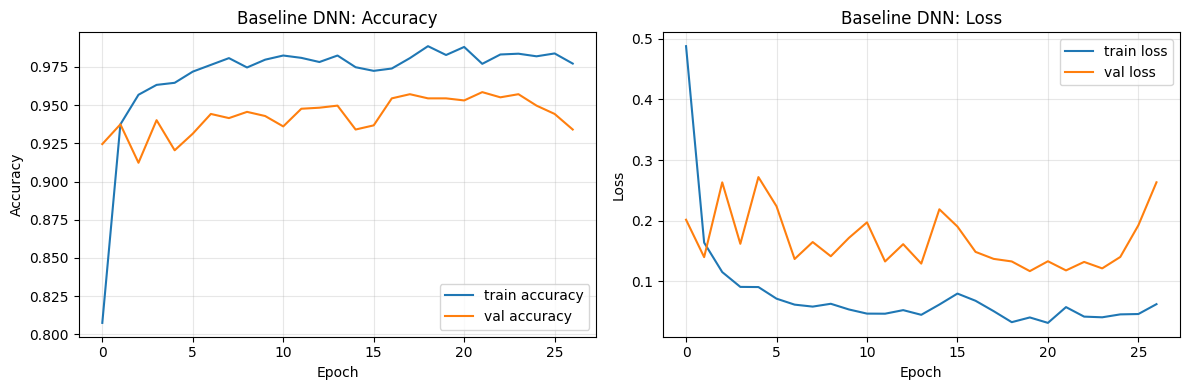

In [9]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="train accuracy")
axes[0].plot(history.history["val_accuracy"], label="val accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline DNN: Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="train loss")
axes[1].plot(history.history["val_loss"], label="val loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline DNN: Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

Baseline Keras test accuracy: 0.9362

Classification report (baseline Keras):
                    precision    recall  f1-score   support

           WALKING     0.9108    0.9879    0.9478       496
  WALKING_UPSTAIRS     0.9477    0.8854    0.9155       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8639    0.9662    0.9122       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9362      2947
         macro avg     0.9397    0.9349    0.9359      2947
      weighted avg     0.9391    0.9362    0.9362      2947



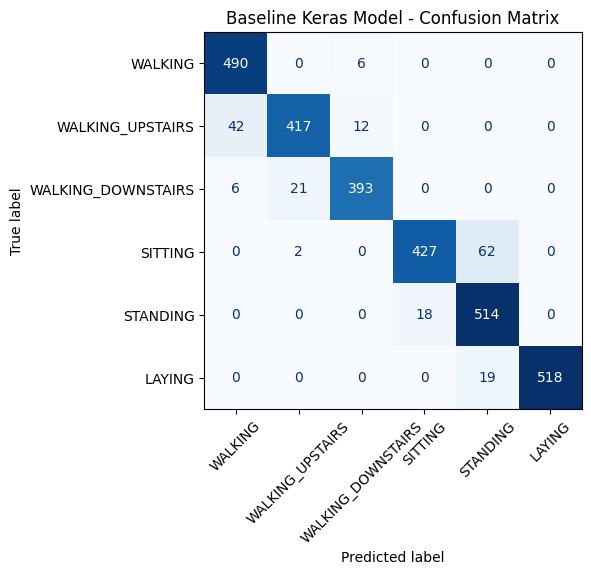

In [10]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_prob_baseline = baseline_model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(y_prob_baseline, axis=1)

baseline_keras_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Keras test accuracy: {baseline_keras_acc:.4f}\n")

print("Classification report (baseline Keras):")
print(classification_report(y_test, y_pred_baseline, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred_baseline)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
)
ax.set_title("Baseline Keras Model - Confusion Matrix")
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [11]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale,  input_zero_point  = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_dtype  = input_details["dtype"]
    output_dtype = output_details["dtype"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the TFLite input tensor expects int8/uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_dtype in (np.int8, np.uint8):
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_dtype)
        else:
            # float32 / float16 models: interpreter expects float32 inputs
            x = x.astype(np.float32)

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output only when the output tensor is int8 or uint8.
        if output_dtype in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    return tflite_model

## 8. Convert the Baseline Model to TensorFlow Lite

In [12]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#
baseline_tflite        = convert_to_tflite_fp32(baseline_model)
baseline_tflite_size   = save_binary_model(baseline_tflite, "baseline_fp32.tflite")
baseline_tflite_acc, _ = evaluate_tflite_model(baseline_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite size    : {baseline_tflite_size:.2f} KB")
print(f"Baseline FP32 TFLite accuracy: {baseline_tflite_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmptvkchegv/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmptvkchegv/assets


Baseline FP32 TFLite size    : 726.72 KB
Baseline FP32 TFLite accuracy: 0.9362


2026-04-22 18:51:35.916688: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:51:35.916716: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:51:35.917197: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmptvkchegv
2026-04-22 18:51:35.918829: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:51:35.918848: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmptvkchegv
2026-04-22 18:51:35.923206: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-22 18:51:35.924595: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:51:35.991936: I tensorflow/cc/saved_model/loader.

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [13]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# Compute steps_per_epoch using 80% of the training set (because validation_split=0.2).
num_train_samples = int(X_train.shape[0] * 0.8)
steps_per_epoch   = int(np.ceil(num_train_samples / batch_size))
end_step          = steps_per_epoch * pruning_epochs

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=end_step,
    )
}

print(f"steps_per_epoch = {steps_per_epoch}")
print(f"end_step        = {end_step}")

# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
base_for_pruning = build_baseline_model(num_features, num_classes)
# Warm start: copy baseline weights so pruning fine-tunes an already-trained model.
base_for_pruning.set_weights(baseline_model.get_weights())

pruned_model = prune_low_magnitude(base_for_pruning, **pruning_params)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
pruned_model.summary()


pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
# Train the pruned model.
pruning_history = pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=2,
)

steps_per_epoch = 92
end_step        = 1104
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 256)               287490    
 4 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 128)               65666     
 5 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 64)                16450     
 6 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 6)                 776       
 7 (PruneLowMagnitude)                                           
                                                                 
Total para

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [14]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#
# --- (1) Pruned model WITH mask -> FP32 TFLite ---
converter_mask = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
pruned_mask_tflite = converter_mask.convert()
pruned_mask_size   = save_binary_model(pruned_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_mask_acc, _ = evaluate_tflite_model(pruned_mask_tflite, X_test, y_test)

print(f"Pruned (with mask) FP32 TFLite size    : {pruned_mask_size:.2f} KB")
print(f"Pruned (with mask) FP32 TFLite accuracy: {pruned_mask_acc:.4f}")

# --- (3) Strip pruning wrappers ---
stripped_model = strip_pruning(pruned_model)
stripped_model.summary()

# --- (4) Convert stripped model with EXPERIMENTAL_SPARSITY ---
converter_stripped = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_stripped.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter_stripped.convert()

stripped_sparse_size   = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, _ = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Stripped sparse FP32 TFLite size    : {stripped_sparse_size:.2f} KB")
print(f"Stripped sparse FP32 TFLite accuracy: {stripped_sparse_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzxpnkmih/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzxpnkmih/assets
2026-04-22 18:52:55.668641: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:52:55.668669: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:52:55.668958: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzxpnkmih
2026-04-22 18:52:55.674505: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:52:55.674531: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzxpnkmih
2026-04-22 18:52:55.691386: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:52:55.790400: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned (with mask) FP32 TFLite size    : 1454.18 KB
Pruned (with mask) FP32 TFLite accuracy: 0.9352
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
INFO:tensorflow:Assets written to: /var/folder

INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpolggu76w/assets


Stripped sparse FP32 TFLite size    : 424.94 KB
Stripped sparse FP32 TFLite accuracy: 0.9352


2026-04-22 18:52:57.593430: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:52:57.593452: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:52:57.593707: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpolggu76w
2026-04-22 18:52:57.594893: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:52:57.594909: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpolggu76w
2026-04-22 18:52:57.597366: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:52:57.625459: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpolggu76w
2026-04-

## 11. Part I Comparison: Accuracy and Model Size

In [15]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
part1_df = pd.DataFrame([
    {
        "Model":          "Baseline",
        "Format":         "FP32 TFLite",
        "Test Accuracy":  baseline_tflite_acc,
        "Model Size (KB)": baseline_tflite_size,
    },
    {
        "Model":          "Pruned (with mask)",
        "Format":         "FP32 TFLite",
        "Test Accuracy":  pruned_mask_acc,
        "Model Size (KB)": pruned_mask_size,
    },
    {
        "Model":          "Stripped sparse",
        "Format":         "FP32 TFLite (EXPERIMENTAL_SPARSITY)",
        "Test Accuracy":  stripped_sparse_acc,
        "Model Size (KB)": stripped_sparse_size,
    },
])
print("Part I - Pruning Comparison:")
print(part1_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Part I - Pruning Comparison:
             Model                              Format  Test Accuracy  Model Size (KB)
          Baseline                         FP32 TFLite         0.9362         726.7188
Pruned (with mask)                         FP32 TFLite         0.9352        1454.1758
   Stripped sparse FP32 TFLite (EXPERIMENTAL_SPARSITY)         0.9352         424.9375


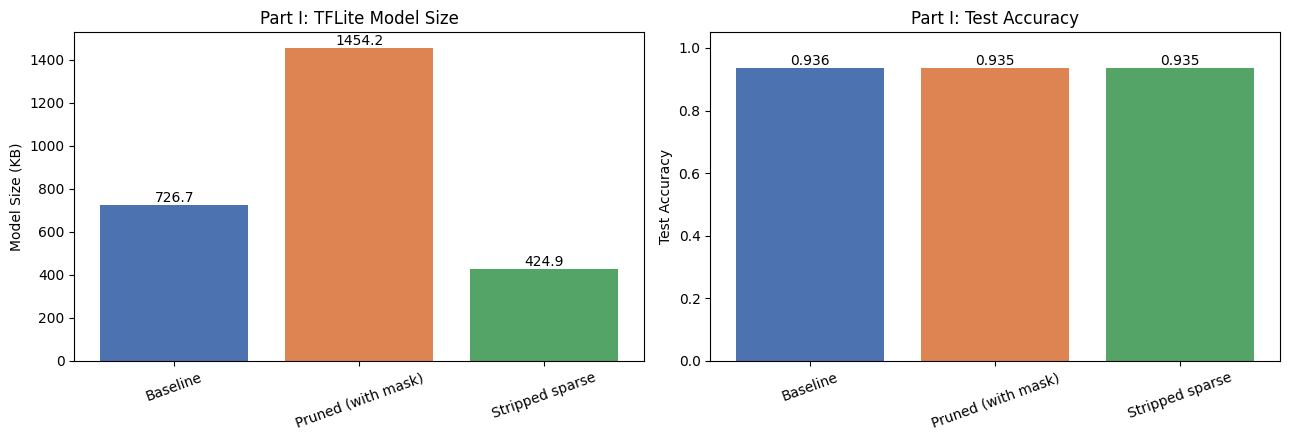

In [16]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = part1_df["Model"].tolist()
sizes  = part1_df["Model Size (KB)"].tolist()
accs   = part1_df["Test Accuracy"].tolist()

bars0 = axes[0].bar(labels, sizes, color=["#4C72B0", "#DD8452", "#55A467"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I: TFLite Model Size")
axes[0].tick_params(axis="x", rotation=20)
for b, v in zip(bars0, sizes):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom")

bars1 = axes[1].bar(labels, accs, color=["#4C72B0", "#DD8452", "#55A467"])
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Part I: Test Accuracy")
axes[1].tick_params(axis="x", rotation=20)
for b, v in zip(bars1, accs):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

Classification report (stripped sparse FP32 TFLite):
                    precision    recall  f1-score   support

           WALKING     0.9232    0.9940    0.9573       496
  WALKING_UPSTAIRS     0.9372    0.9193    0.9282       471
WALKING_DOWNSTAIRS     0.9746    0.9143    0.9435       420
           SITTING     0.9530    0.8676    0.9083       491
          STANDING     0.8502    0.9605    0.9020       532
            LAYING     1.0000    0.9479    0.9732       537

          accuracy                         0.9352      2947
         macro avg     0.9397    0.9339    0.9354      2947
      weighted avg     0.9386    0.9352    0.9354      2947



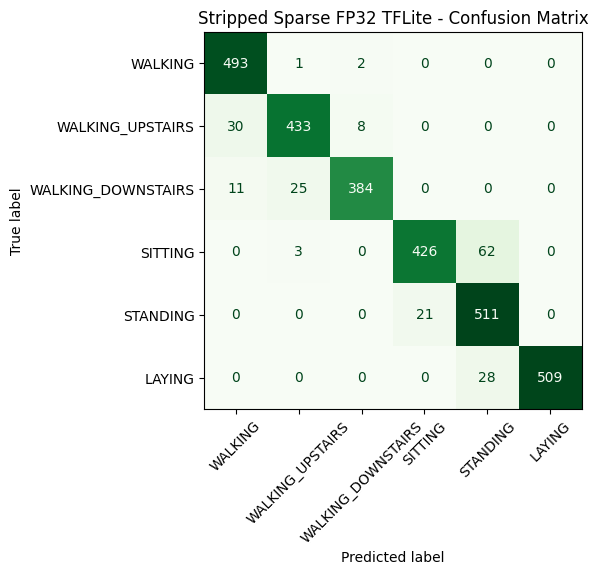

In [17]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
# Confusion matrix + classification report for the stripped sparse TFLite model.
_, y_pred_stripped = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print("Classification report (stripped sparse FP32 TFLite):")
print(classification_report(y_test, y_pred_stripped, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred_stripped)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Greens", colorbar=False
)
ax.set_title("Stripped Sparse FP32 TFLite - Confusion Matrix")
plt.tight_layout()
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [18]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
conv_fp16_mask = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
conv_fp16_mask.optimizations       = [tf.lite.Optimize.DEFAULT]
conv_fp16_mask.target_spec.supported_types = [tf.float16]
pruned_mask_fp16_tflite = conv_fp16_mask.convert()

pruned_mask_fp16_size   = save_binary_model(pruned_mask_fp16_tflite, "pruned_with_mask_fp16.tflite")
pruned_mask_fp16_acc, _ = evaluate_tflite_model(pruned_mask_fp16_tflite, X_test, y_test)

print(f"Pruned (with mask) FP16 TFLite size    : {pruned_mask_fp16_size:.2f} KB")
print(f"Pruned (with mask) FP16 TFLite accuracy: {pruned_mask_fp16_acc:.4f}")

# --- (3) Stripped sparse -> float16 + sparsity-aware TFLite ---
conv_fp16_stripped = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
conv_fp16_stripped.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY,
]
conv_fp16_stripped.target_spec.supported_types = [tf.float16]
stripped_sparse_fp16_tflite = conv_fp16_stripped.convert()

stripped_sparse_fp16_size   = save_binary_model(stripped_sparse_fp16_tflite, "stripped_sparse_fp16.tflite")
stripped_sparse_fp16_acc, _ = evaluate_tflite_model(stripped_sparse_fp16_tflite, X_test, y_test)

print(f"Stripped sparse FP16 TFLite size    : {stripped_sparse_fp16_size:.2f} KB")
print(f"Stripped sparse FP16 TFLite accuracy: {stripped_sparse_fp16_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpo5hlqg85/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpo5hlqg85/assets
2026-04-22 18:53:02.791075: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:53:02.791096: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:53:02.791343: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpo5hlqg85
2026-04-22 18:53:02.795915: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:53:02.795930: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpo5hlqg85
2026-04-22 18:53:02.808707: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:53:02.895587: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned (with mask) FP16 TFLite size    : 732.59 KB
Pruned (with mask) FP16 TFLite accuracy: 0.9352
INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzr_dryx0/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzr_dryx0/assets


Stripped sparse FP16 TFLite size    : 279.99 KB
Stripped sparse FP16 TFLite accuracy: 0.9352


2026-04-22 18:53:04.625119: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:53:04.625144: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:53:04.625438: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzr_dryx0
2026-04-22 18:53:04.626392: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:53:04.626406: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzr_dryx0
2026-04-22 18:53:04.630325: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:53:04.661985: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpzr_dryx0
2026-04-

## 12. Part II Comparison: Accuracy and Model Size

In [19]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#
part2_df = pd.DataFrame([
    {
        "Model":          "Pruned (with mask)",
        "Format":         "FP32 TFLite",
        "Test Accuracy":  pruned_mask_acc,
        "Model Size (KB)": pruned_mask_size,
    },
    {
        "Model":          "Stripped sparse",
        "Format":         "FP32 TFLite (EXPERIMENTAL_SPARSITY)",
        "Test Accuracy":  stripped_sparse_acc,
        "Model Size (KB)": stripped_sparse_size,
    },
    {
        "Model":          "Pruned (with mask)",
        "Format":         "FP16 TFLite",
        "Test Accuracy":  pruned_mask_fp16_acc,
        "Model Size (KB)": pruned_mask_fp16_size,
    },
    {
        "Model":          "Stripped sparse",
        "Format":         "FP16 TFLite (EXPERIMENTAL_SPARSITY)",
        "Test Accuracy":  stripped_sparse_fp16_acc,
        "Model Size (KB)": stripped_sparse_fp16_size,
    },
])
print("Part II - Pruning + Float16 Comparison:")
print(part2_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Part II - Pruning + Float16 Comparison:
             Model                              Format  Test Accuracy  Model Size (KB)
Pruned (with mask)                         FP32 TFLite         0.9352        1454.1758
   Stripped sparse FP32 TFLite (EXPERIMENTAL_SPARSITY)         0.9352         424.9375
Pruned (with mask)                         FP16 TFLite         0.9352         732.5859
   Stripped sparse FP16 TFLite (EXPERIMENTAL_SPARSITY)         0.9352         279.9922


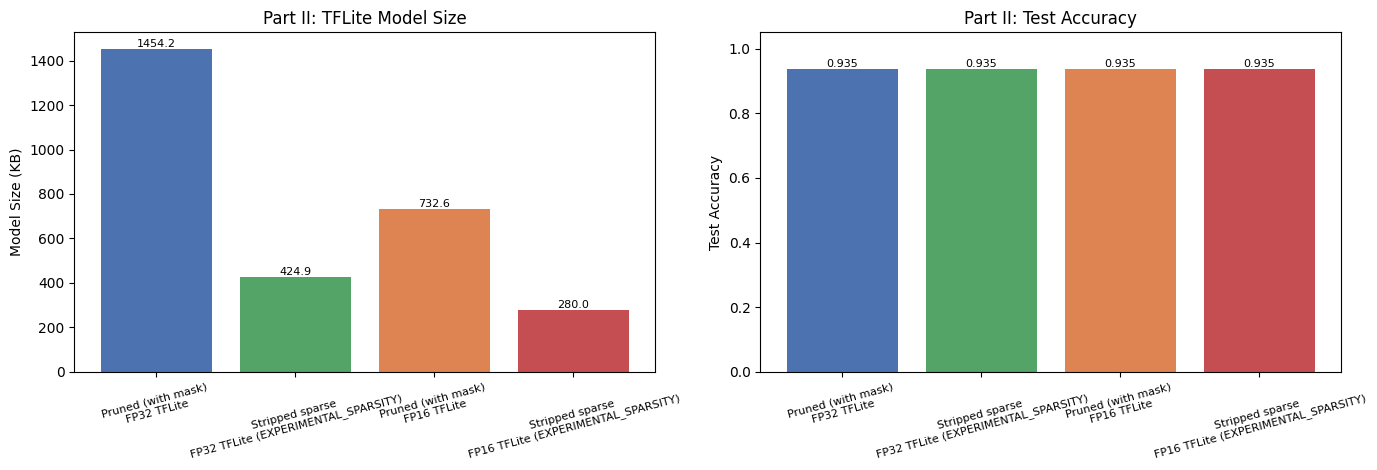

In [20]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

labels = [f"{m}\n{f}" for m, f in zip(part2_df["Model"], part2_df["Format"])]
sizes  = part2_df["Model Size (KB)"].tolist()
accs   = part2_df["Test Accuracy"].tolist()
colors = ["#4C72B0", "#55A467", "#DD8452", "#C44E52"]

bars0 = axes[0].bar(labels, sizes, color=colors)
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II: TFLite Model Size")
axes[0].tick_params(axis="x", rotation=15, labelsize=8)
for b, v in zip(bars0, sizes):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

bars1 = axes[1].bar(labels, accs, color=colors)
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Part II: Test Accuracy")
axes[1].tick_params(axis="x", rotation=15, labelsize=8)
for b, v in zip(bars1, accs):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

Classification report (stripped sparse + FP16 TFLite):
                    precision    recall  f1-score   support

           WALKING     0.9232    0.9940    0.9573       496
  WALKING_UPSTAIRS     0.9372    0.9193    0.9282       471
WALKING_DOWNSTAIRS     0.9746    0.9143    0.9435       420
           SITTING     0.9530    0.8676    0.9083       491
          STANDING     0.8502    0.9605    0.9020       532
            LAYING     1.0000    0.9479    0.9732       537

          accuracy                         0.9352      2947
         macro avg     0.9397    0.9339    0.9354      2947
      weighted avg     0.9386    0.9352    0.9354      2947



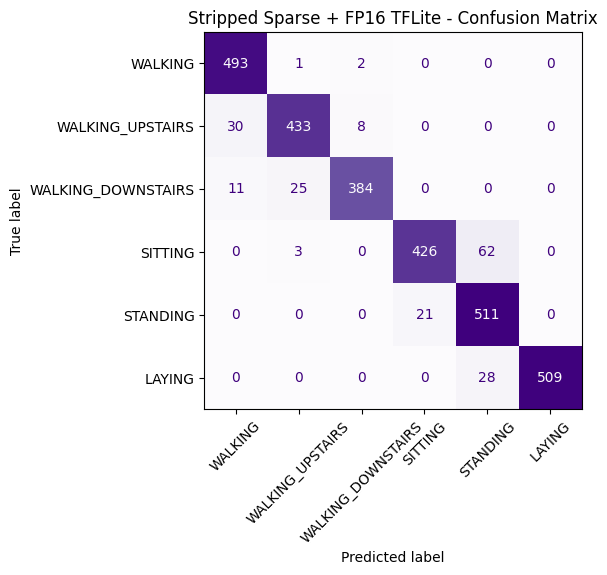

In [21]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#
# Confusion matrix + classification report for the stripped sparse + float16 TFLite model.
_, y_pred_stripped_fp16 = evaluate_tflite_model(stripped_sparse_fp16_tflite, X_test, y_test)

print("Classification report (stripped sparse + FP16 TFLite):")
print(classification_report(y_test, y_pred_stripped_fp16, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred_stripped_fp16)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Purples", colorbar=False
)
ax.set_title("Stripped Sparse + FP16 TFLite - Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
   No — it actually made the file bigger. The baseline FP32 model was 726.72 KB, but the pruned model with the wrappers still attached came out to 1454.18   KB, almost exactly 2× larger. 
2. Why does `strip_pruning(...)` matter before export? strip_pruning removes the PruneLowMagnitude wrapper layers and collapses each layer back into a plain Keras Dense whose weight tensor contains the final sparse values directly — no mask, no shadow weights. Only after stripping can the TFLite converter (with tf.lite.Optimize.EXPERIMENTAL_SPARSITY) recognize the ~85% zero pattern and store the weights in a compressed sparse encoding instead of as a dense matrix of mostly zeros.
3. Which model had the smallest file size in this notebook? The stripped sparse + float16 TFLite model at 279.99 KB. That's roughly 2.6× smaller than the baseline (726.72 KB → 279.99 KB) and still hits 0.9352 test accuracy.
4. Did float16 quantization noticeably change the test accuracy? No. Every model in both tables — FP32 baseline, FP32 pruned, FP32 stripped sparse, FP16 pruned with mask, and FP16 stripped sparse — landed at either 0.9362 or 0.9352 test accuracy
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?The stripped sparse + float16 TFLite model. It gives the smallest flash footprint (279.99 KB vs 726.72 KB for the baseline — a 61% reduction), keeps test accuracy essentially identical (0.9352 vs 0.9362, well within noise), and benefits at inference time from both the float16 weight format and the sparsely-encoded weight matrix.



## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
